# 01 - LMS Foundations and ANC Demos

**Standalone demo notes**

Least Mean Squares (LMS) is the baseline adaptive-filtering algorithm behind the rest of this repository. It learns an FIR filter by using the current error sample as a stochastic estimate of the gradient of mean-square error.

Adaptive-filter vector:

$$
\mathbf{x}[n] =
\begin{bmatrix}
x[n] & x[n-1] & \cdots & x[n-M+1]
\end{bmatrix}^T
$$

Filter output and error:

$$
y[n] = \mathbf{w}_n^T\mathbf{x}[n], \qquad e[n] = d[n] - y[n]
$$

Objective:

$$
J(\mathbf{w}) = E\{e^2[n]\}
$$

LMS update:

$$
\mathbf{w}_{n+1} = \mathbf{w}_n + \mu e[n]\mathbf{x}[n]
$$

Practical note: larger $\mu$ adapts faster but can become unstable. Smaller $\mu$ is safer but slower. This notebook shows LMS in three settings: system identification, one-microphone adaptive line enhancement, and two-microphone feedforward noise cancellation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4)


## 1. System Identification

Goal: learn an unknown FIR plant from a known input and measured output. This is the cleanest way to see LMS coefficient adaptation before moving into ANC signal models.


In [2]:
N = 700
n = np.arange(N)

x = (
    np.sin(2 * np.pi * 0.035 * n)
    + 0.6 * np.sin(2 * np.pi * 0.12 * n)
    + 0.25 * np.random.randn(N)
)

h_true = np.array([0.30, 0.60, 0.20, -0.10, 0.05, 0.00, 0.00, 0.00])
d_clean = np.convolve(x, h_true, mode='full')[:N]
d = d_clean + 0.12 * np.random.randn(N)

M = len(h_true)
mu = 0.025

y = np.zeros(N)
e = np.zeros(N)
w = np.zeros(M)

for i in range(M - 1, N):
    x_vec = x[i - M + 1 : i + 1][::-1]
    y[i] = np.dot(w, x_vec)
    e[i] = d[i] - y[i]
    w = w + mu * e[i] * x_vec

print('True plant taps: ', np.round(h_true, 4))
print('Learned taps:    ', np.round(w, 4))


True plant taps:  [ 0.3   0.6   0.2  -0.1   0.05  0.    0.    0.  ]
Learned taps:     [ 0.3555  0.5052  0.1962 -0.0302  0.0248 -0.017   0.0089  0.0123]


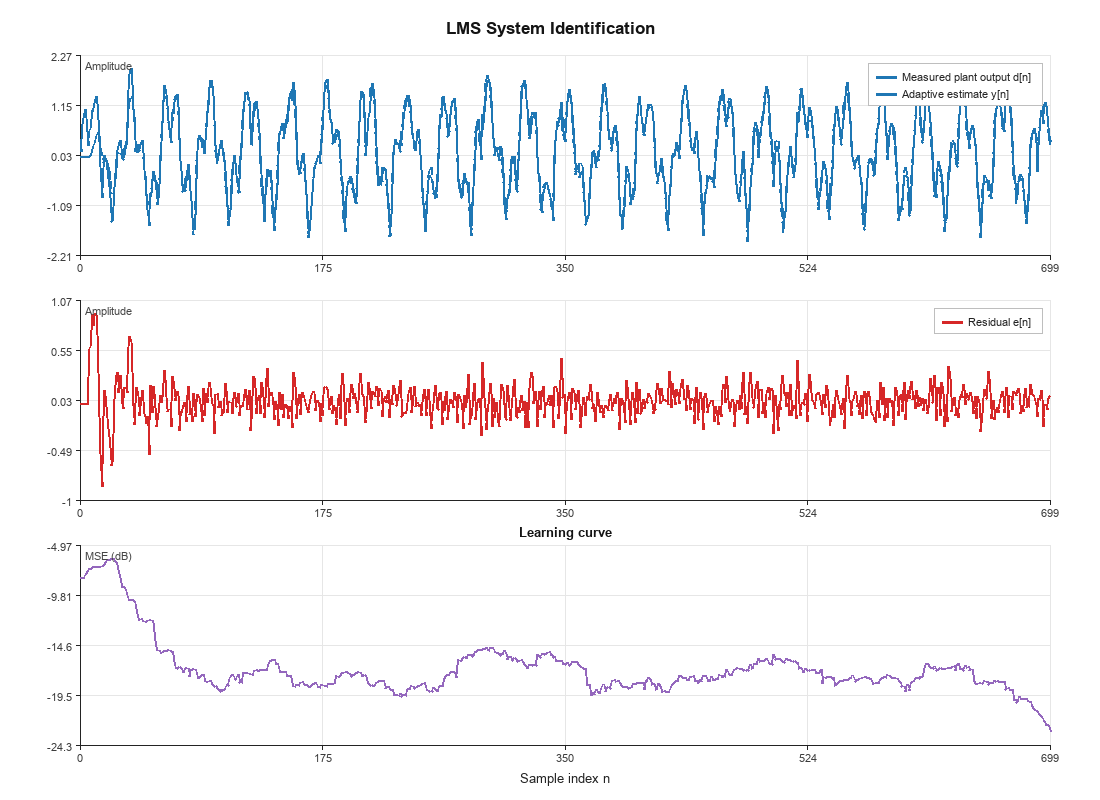

In [3]:
mse = np.convolve(e**2, np.ones(35) / 35, mode='same')

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle('LMS System Identification', fontsize=13)

axes[0].plot(n, d, label='Measured plant output d[n]', alpha=0.65)
axes[0].plot(n, y, label='Adaptive estimate y[n]', linestyle='--')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(n, e, color='tab:red', label='Residual e[n]')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(10 * np.log10(mse + 1e-12), color='tab:purple')
axes[2].set_xlabel('Sample index n')
axes[2].set_ylabel('MSE (dB)')
axes[2].set_title('Learning curve')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## 2. Adaptive Line Enhancer

Goal: reduce noise with one sensor by predicting the correlated part of a noisy signal from a delayed copy. The delay decorrelates broadband noise more than it decorrelates a tonal or slowly varying signal.

Here $x[n] = d[n] + v[n]$, the adaptive filter input is a delayed vector $\mathbf{x}_\Delta[n]$, and $y[n]$ becomes the enhanced estimate of $d[n]$.


In [4]:
np.random.seed(8)

N = 1000
n = np.arange(N)

desired = (
    np.sin(2 * np.pi * 0.035 * n)
    + 0.45 * np.sin(2 * np.pi * 0.075 * n)
)
noise = 0.55 * np.random.randn(N)
x = desired + noise

delay = 10
M = 16
mu = 0.018

y = np.zeros(N)
e = np.zeros(N)
w = np.zeros(M)

for i in range(delay + M - 1, N):
    x_delayed = x[i - delay - M + 1 : i - delay + 1][::-1]
    y[i] = np.dot(w, x_delayed)
    e[i] = x[i] - y[i]
    w = w + mu * e[i] * x_delayed

input_snr = 10 * np.log10(np.var(desired) / np.var(noise))
steady = slice(N // 2, None)
output_snr = 10 * np.log10(
    np.var(desired[steady]) / (np.var(desired[steady] - y[steady]) + 1e-12)
)

print(f'Input SNR:          {input_snr:.2f} dB')
print(f'LMS ALE output SNR: {output_snr:.2f} dB')
print(f'SNR improvement:    {output_snr - input_snr:.2f} dB')


Input SNR:          2.80 dB
LMS ALE output SNR: 5.48 dB
SNR improvement:    2.69 dB


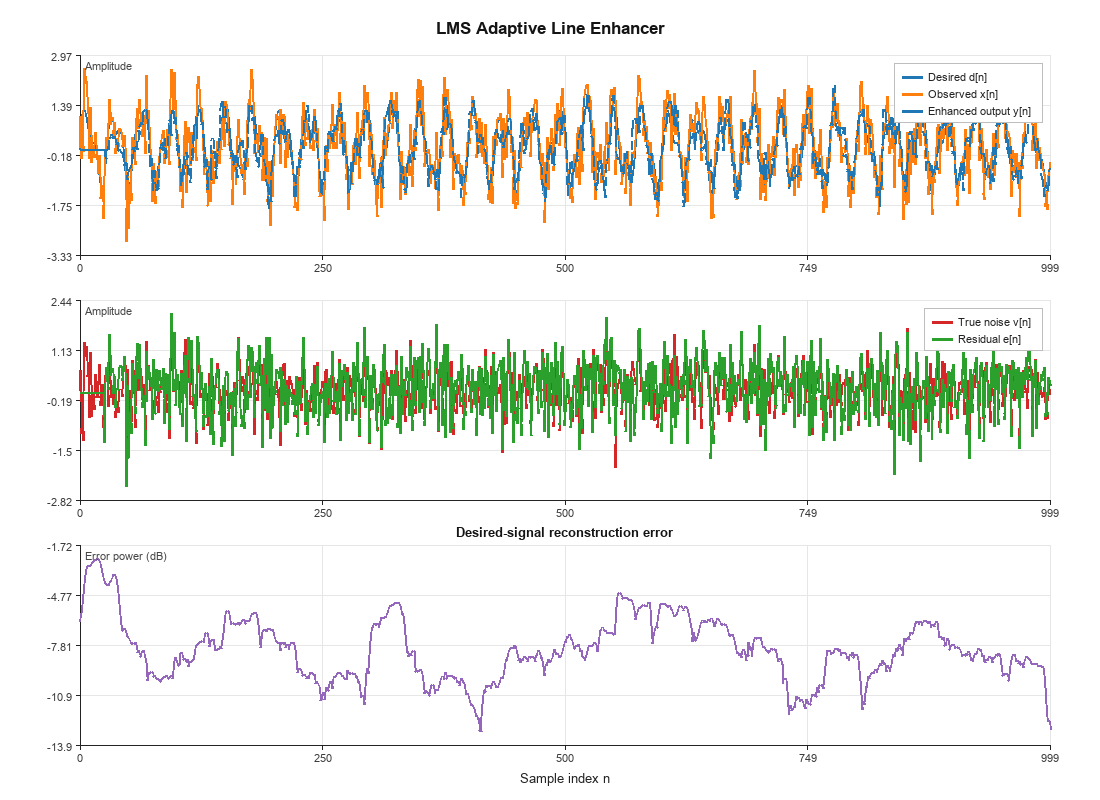

In [5]:
err = np.convolve((desired - y) ** 2, np.ones(35) / 35, mode='same')

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle('LMS Adaptive Line Enhancer', fontsize=13)

axes[0].plot(n, desired, label='Desired d[n]', lw=1.5)
axes[0].plot(n, x, label='Observed x[n]', color='tab:orange', alpha=0.35)
axes[0].plot(n, y, label='Enhanced output y[n]', linestyle='--')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(n, noise, label='True noise v[n]', color='tab:red', alpha=0.45)
axes[1].plot(n, e, label='Residual e[n]', color='tab:green', alpha=0.75)
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(10 * np.log10(err + 1e-12), color='tab:purple')
axes[2].set_xlabel('Sample index n')
axes[2].set_ylabel('Error power (dB)')
axes[2].set_title('Desired-signal reconstruction error')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## 3. Feedforward Noise Cancellation

Goal: use a separate reference microphone to estimate the noise contaminating a primary microphone.

Primary microphone:

$$
d[n] = s[n] + v_p[n]
$$

The adaptive filter learns $y[n] \approx v_p[n]$, so the cleaned output is $e[n] = d[n] - y[n]$. This is a direct-subtraction model, useful for denoising and for building intuition before the physical secondary path is added in the Filtered-x notebook.


In [6]:
np.random.seed(12)

N = 4000
n = np.arange(N)

desired = np.sin(2 * np.pi * 0.018 * n) + 0.5 * np.sin(2 * np.pi * 0.045 * n)
noise_source = np.random.randn(N)

reference_path = np.array([1.0, 0.55, 0.25, -0.10])
primary_path = np.array([0.45, 0.20, -0.08])

x = np.convolve(noise_source, reference_path, mode='full')[:N]
primary_noise = np.convolve(noise_source, primary_path, mode='full')[:N]
d = desired + primary_noise

M = 16
mu = 0.006

y = np.zeros(N)
e = np.zeros(N)
w = np.zeros(M)

for i in range(M - 1, N):
    x_vec = x[i - M + 1 : i + 1][::-1]
    y[i] = np.dot(w, x_vec)
    e[i] = d[i] - y[i]
    w = w + mu * e[i] * x_vec

input_snr = 10 * np.log10(np.var(desired) / np.var(primary_noise))
steady = slice(N // 2, None)
output_snr = 10 * np.log10(
    np.var(desired[steady]) / (np.var(desired[steady] - e[steady]) + 1e-12)
)

print(f'Input SNR at primary mic:     {input_snr:.2f} dB')
print(f'LMS feedforward output SNR:   {output_snr:.2f} dB')
print(f'SNR improvement:              {output_snr - input_snr:.2f} dB')


Input SNR at primary mic:     4.12 dB
LMS feedforward output SNR:   9.21 dB
SNR improvement:              5.09 dB


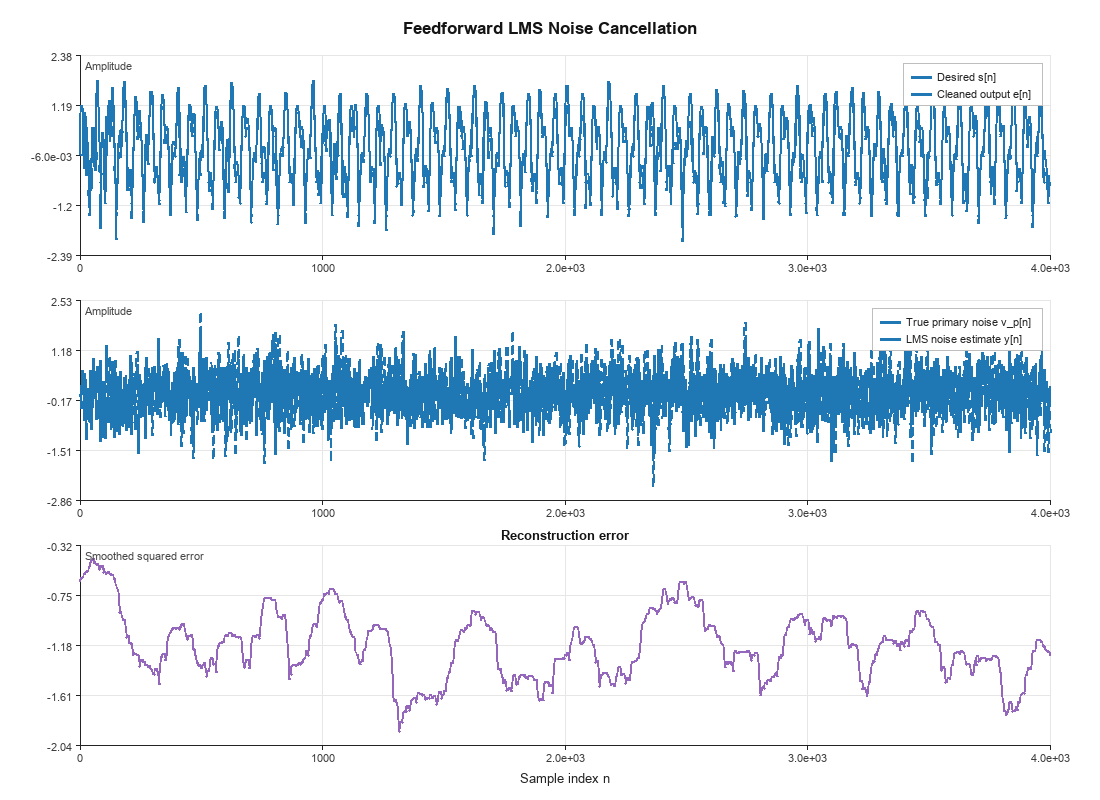

In [7]:
err = np.convolve((desired - e) ** 2, np.ones(100) / 100, mode='same')

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Feedforward LMS Noise Cancellation', fontsize=13)

axes[0].plot(n, desired, label='Desired s[n]', lw=1.5)
axes[0].plot(n, e, label='Cleaned output e[n]', alpha=0.8)
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(n, primary_noise, label='True primary noise v_p[n]', alpha=0.65)
axes[1].plot(n, y, label='LMS noise estimate y[n]', linestyle='--')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True)

axes[2].semilogy(err, color='tab:purple')
axes[2].set_xlabel('Sample index n')
axes[2].set_ylabel('Smoothed squared error')
axes[2].set_title('Reconstruction error')
axes[2].grid(True)

plt.tight_layout()
plt.show()
